<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/00_OpenMeteo_HourlyWeather_Seoul_Busan_NewYork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Open-Meteo Weather (시간별) — Seoul / Busan / New York


> **학습목표 (전체(이 노트북))**
>
- Open-Meteo API로 **가입/키 없이** 도시별 시간별 날씨 시계열을 수집한다.
- 시간별 데이터에서 시간대(timezone)·결측·리샘플링(시간→일) 이슈를 처리한다.
- 계절/일주기 패턴을 시각화·STL·ACF로 진단하고, 간단 베이스라인 예측을 만든다.


### 🧭 수업 맥락(생활 데이터)
- 날씨는 학생들이 즉시 공감하는 데이터이며, **일주기(24시간) 패턴**이 매우 뚜렷해 ACF/STL 설명에 적합합니다.
- 또한 **시간대(timezone)**, **리샘플링(시간→일)**, **결측 처리** 등 실무형 이슈를 자연스럽게 다룰 수 있습니다.


## 0) 데이터 설명: Open-Meteo API (가입/키 필요 없음)
**무엇을 주나?**
- 전세계 좌표(lat/lon)에 대한 **시간별/일별** 기상 변수(기온, 강수, 풍속, 습도 등)를 제공합니다.

**가입/키 필요?**
- **필요 없습니다.** (공개 API)

**API 엔드포인트(대표)**
- `https://api.open-meteo.com/v1/forecast`

**핵심 파라미터**
- `latitude`, `longitude`: 위치
- `hourly`: 받을 시간별 변수 목록 (예: `temperature_2m`, `precipitation`, `relative_humidity_2m`)
- `start_date`, `end_date`: `YYYY-MM-DD`
- `timezone`: `auto` 또는 `Asia/Seoul` 등 (시간대 정합성에 중요)

**주의(수업 운영 팁)**
- 날씨 API는 예보/재분석 데이터 성격이 섞일 수 있어, ‘정답’보다는 **패턴 진단**과 **모형 비교**에 초점을 두는 것이 좋습니다.
- 요청이 많으면 속도 제한이 있을 수 있으므로, 실습에서는 (1) 기간을 짧게(예: 30~90일) 하거나 (2) 도시 수를 제한하는 것이 안정적입니다.


## 1) 라이브러리/환경


In [10]:
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (12, 4)


## 2) 도시 좌표(Seoul / Busan / New York)
Open-Meteo는 위도/경도를 필요로 합니다. 수업에서는 아래처럼 좌표를 직접 넣거나,
별도로 지오코딩(예: Nominatim)으로 도시명을 좌표로 바꾸는 방식도 가능하지만, 안정성을 위해 여기서는 좌표를 고정합니다.


> **학습목표 (2) 좌표)**
>
- 도시 → 위도/경도 매핑을 이해한다.
- 시간대(timezone)를 도시별로 자동 처리하는 옵션을 이해한다.


In [11]:
CITIES = {
    'Seoul':   {'lat': 37.5665, 'lon': 126.9780},
    'Busan':   {'lat': 35.1796, 'lon': 129.0756},
    'NewYork': {'lat': 40.7128, 'lon': -74.0060},
}
CITIES


{'Seoul': {'lat': 37.5665, 'lon': 126.978},
 'Busan': {'lat': 35.1796, 'lon': 129.0756},
 'NewYork': {'lat': 40.7128, 'lon': -74.006}}

### 🔎 출력 해석 포인트 (좌표/시간대)
- Open-Meteo는 좌표 기반이므로 도시명 대신 위도/경도 입력이 필요합니다.
- `timezone='auto'`를 쓰면 각 도시의 현지 시간대 기준으로 시간이 반환됩니다.
- 다도시 비교를 할 때는 ‘동일한 시간대’로 맞추거나, ‘각 도시 현지 시간’으로 비교할지 목적을 정해야 합니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. Open-Meteo 호출에 필수인 위치 정보는 (_____)와 (_____)이다.
- Q2. `timezone='auto'`는 도시의 (_____) 시간대를 자동 적용한다.
- Q3. 다도시를 비교할 때 시간대 정합성은 매우 (_____)하다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. latitude
- A2. longitude
- A3. 현지(local)
- A4. 중요

</details>


## 3) Open-Meteo 호출 함수(시간별)
여기서는 최근 30일(기본값)의 시간별 데이터를 가져옵니다. 원하면 `START_DATE`, `END_DATE`를 늘리거나 줄이면 됩니다.


> **학습목표 (3) 수집)**
>
- Open-Meteo에서 시간별 변수를 지정해 가져온다.
- 반환 JSON을 DataFrame(시간 인덱스)으로 변환한다.
- 도시별 DataFrame을 합쳐 멀티 시계열로 만든다.


In [12]:
BASE = 'https://api.open-meteo.com/v1/forecast'
START_DATE = '2026-02-05'
END_DATE   = '2026-03-07'

HOURLY_VARS = [
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'windspeed_10m'
]

def fetch_open_meteo_hourly(lat: float, lon: float,
                            start_date: str = START_DATE,
                            end_date: str = END_DATE,
                            hourly_vars: list[str] = HOURLY_VARS,
                            timezone: str = 'auto',
                            sleep_sec: float = 0.2,
                            session: requests.Session | None = None) -> pd.DataFrame:
    sess = session or requests.Session()
    params = {
        'latitude': lat,
        'longitude': lon,
        'hourly': ','.join(hourly_vars),
        'start_date': start_date,
        'end_date': end_date,
        'timezone': timezone,
    }
    r = sess.get(BASE, params=params, timeout=30)
    if r.status_code != 200:
        raise RuntimeError(f"HTTP {r.status_code}: {r.text[:200]}")
    js = r.json()
    hourly = js.get('hourly', {})
    if 'time' not in hourly:
        return pd.DataFrame()
    df = pd.DataFrame(hourly)
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time').sort_index()
    # API 예의상 짧게 쉬기
    time.sleep(sleep_sec)
    return df

def fetch_cities_weather(cities: dict) -> dict:
    sess = requests.Session()
    out = {}
    for name, loc in cities.items():
        out[name] = fetch_open_meteo_hourly(loc['lat'], loc['lon'], session=sess)
    return out


### 🔎 출력 해석 포인트 (API 호출)
- Open-Meteo는 쿼리스트링 파라미터로 위치·기간·변수를 전달합니다.
- 반환되는 `hourly`는 time 배열과 변수 배열(동일 길이)로 구성됩니다.
- timezone을 명시해야 ‘현지 시간 기준’의 일주기 패턴이 깔끔해집니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. Open-Meteo는 인증키가 (_____) (필요/불필요)하다.
- Q2. 시간별 변수 목록은 파라미터 (_____)에 콤마로 전달한다.
- Q3. 일주기 패턴을 보기 위해 중요한 파라미터는 (_____)이다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 불필요
- A2. hourly
- A3. timezone

</details>


## 4) 데이터 수집 실행 및 구조 점검


In [13]:
city_dfs = fetch_cities_weather(CITIES)
for k, v in city_dfs.items():
    print(k, v.shape, v.index.min(), '->', v.index.max())

display(city_dfs['Seoul'].head())


Seoul (744, 4) 2026-02-05 00:00:00 -> 2026-03-07 23:00:00
Busan (744, 4) 2026-02-05 00:00:00 -> 2026-03-07 23:00:00
NewYork (744, 4) 2026-02-05 00:00:00 -> 2026-03-07 23:00:00


,temperature_2m,relative_humidity_2m,precipitation,windspeed_10m
time,,,,
2026-02-05 00:00:00,0.1,88,0.0,3.5
2026-02-05 01:00:00,-0.1,89,0.0,3.8
2026-02-05 02:00:00,-0.3,90,0.0,3.6
2026-02-05 03:00:00,-1.0,94,0.0,4.0
2026-02-05 04:00:00,-1.2,96,0.0,3.4


### 🔎 출력 해석 포인트 (구조 점검)
- 행은 시간(time), 열은 기상 변수입니다.
- 도시별로 동일 변수·동일 길이가 들어오면 병합이 쉽습니다.
- 결측이 있으면(드물지만) 시간 재색인 후 처리합니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 이 데이터의 인덱스는 (_____) 단위이다.
- Q2. 여러 도시를 합칠 때 가장 먼저 확인할 것은 각 DF의 (_____) 일치 여부다.
- Q3. 결측이 있으면 시간 인덱스를 (_____)한 뒤 채움/보간을 고려한다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 시간(시간별)
- A2. 컬럼(변수)
- A3. 재색인(reindex)

</details>


## 5) 멀티 시계열로 합치기(도시×변수)
분석 편의상 컬럼을 (도시, 변수) MultiIndex로 만들거나, `Seoul_temperature_2m`처럼 접두어를 붙일 수 있습니다.


In [14]:
# (A) MultiIndex 컬럼
df_multi = pd.concat(city_dfs, axis=1)
display(df_multi.head())
print(df_multi.columns)

# (B) 단일 레벨 컬럼(접두어)
df_flat = df_multi.copy()
df_flat.columns = [f"{city}_{var}" for city, var in df_flat.columns]
display(df_flat.head())


Seoul                                     \
                    temperature_2m relative_humidity_2m precipitation   
time                                                                    
2026-02-05 00:00:00            0.1                   88           0.0   
2026-02-05 01:00:00           -0.1                   89           0.0   
2026-02-05 02:00:00           -0.3                   90           0.0   
2026-02-05 03:00:00           -1.0                   94           0.0   
2026-02-05 04:00:00           -1.2                   96           0.0   

                                           Busan                       \
                    windspeed_10m temperature_2m relative_humidity_2m   
time                                                                    
2026-02-05 00:00:00           3.5            2.9                   76   
2026-02-05 01:00:00           3.8            2.2                   77   
2026-02-05 02:00:00           3.6            2.0                   76   
2026-02-05 03:00:00           4.0            1.5                   77   
2026-02-05 04:00:00           3.4            1.3                   77   

                                                       NewYork  \
                    precipitation windspeed_10m temperature_2m   
time                                                             
2026-02-05 00:00:00           0.0           7.6           -6.5   
2026-02-05 01:00:00           0.0           6.9           -7.4   
2026-02-05 02:00:00           0.0           6.6           -7.0   
2026-02-05 03:00:00           0.0           7.6           -7.9   
2026-02-05 04:00:00           0.0           7.4           -6.9   

                                                                      
                    relative_humidity_2m precipitation windspeed_10m  
time                                                                  
2026-02-05 00:00:00                   50           0.0           7.1  
2026-02-05 01:00:00                   61           0.0           9.3  
2026-02-05 02:00:00                   53           0.0           8.2  
2026-02-05 03:00:00                   61           0.0           6.9  
2026-02-05 04:00:00                   60           0.0           9.8

MultiIndex([(  'Seoul',       'temperature_2m'),
            (  'Seoul', 'relative_humidity_2m'),
            (  'Seoul',        'precipitation'),
            (  'Seoul',        'windspeed_10m'),
            (  'Busan',       'temperature_2m'),
            (  'Busan', 'relative_humidity_2m'),
            (  'Busan',        'precipitation'),
            (  'Busan',        'windspeed_10m'),
            ('NewYork',       'temperature_2m'),
            ('NewYork', 'relative_humidity_2m'),
            ('NewYork',        'precipitation'),
            ('NewYork',        'windspeed_10m')],
           )


,Seoul_temperature_2m,Seoul_relative_humidity_2m,Seoul_precipitation,Seoul_windspeed_10m,Busan_temperature_2m,Busan_relative_humidity_2m,Busan_precipitation,Busan_windspeed_10m,NewYork_temperature_2m,NewYork_relative_humidity_2m,NewYork_precipitation,NewYork_windspeed_10m
time,,,,,,,,,,,,
2026-02-05 00:00:00,0.1,88,0.0,3.5,2.9,76,0.0,7.6,-6.5,50,0.0,7.1
2026-02-05 01:00:00,-0.1,89,0.0,3.8,2.2,77,0.0,6.9,-7.4,61,0.0,9.3
2026-02-05 02:00:00,-0.3,90,0.0,3.6,2.0,76,0.0,6.6,-7.0,53,0.0,8.2
2026-02-05 03:00:00,-1.0,94,0.0,4.0,1.5,77,0.0,7.6,-7.9,61,0.0,6.9
2026-02-05 04:00:00,-1.2,96,0.0,3.4,1.3,77,0.0,7.4,-6.9,60,0.0,9.8


### 🔎 출력 해석 포인트 (멀티시계열 구조)
- MultiIndex는 `df_multi['Seoul']['temperature_2m']`처럼 계층 접근이 가능합니다.
- Flat 컬럼은 모델 입력(ML)에서 편리한 경우가 많습니다.
- 둘 중 무엇이 좋은지는 ‘후속 작업(시각화/모델링)’에 따라 달라집니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. MultiIndex 방식에서 서울 기온 컬럼은 대략 (_____)로 접근한다.
- Q2. Flat 컬럼 방식은 컬럼명이 (도시)_(_____) 형태다.
- Q3. ML 피처 엔지니어링에서는 보통 (_____) 컬럼이 편한 경우가 많다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. `df_multi['Seoul']['temperature_2m']`
- A2. 변수
- A3. Flat(단일레벨)

</details>


## 6) 시각화: 도시별 시간별 기온(temperature_2m)
일주기(24시간) 패턴과 도시 간 수준 차이를 관찰합니다.


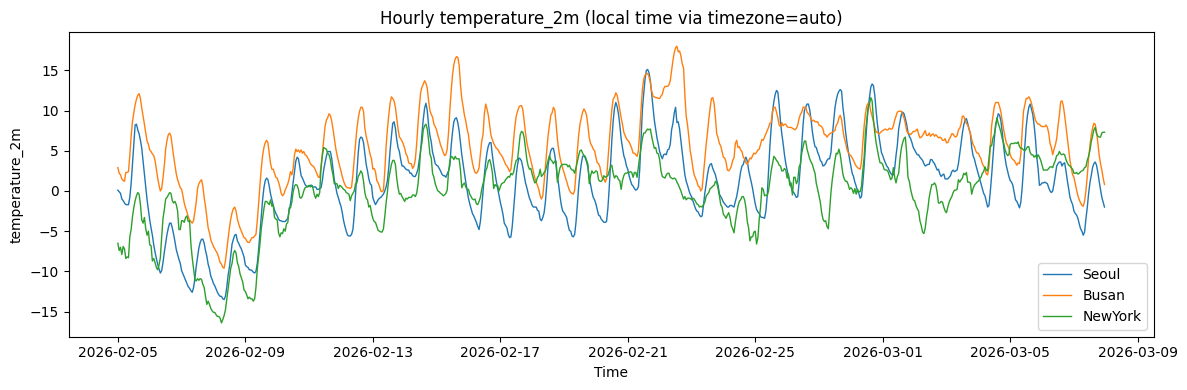

In [15]:
var = 'temperature_2m'
plt.figure(figsize=(12,4))
for city in CITIES.keys():
    plt.plot(df_multi[(city, var)].index, df_multi[(city, var)], label=city, lw=1)
plt.title(f'Hourly {var} (local time via timezone=auto)')
plt.xlabel('Time'); plt.ylabel(var)
plt.legend(); plt.tight_layout(); plt.show()


### 🔎 출력 해석 포인트 (시각화 해석)
- 시간별 기온은 보통 하루 주기로 상승·하강 패턴이 반복됩니다.
- 도시별 평균 수준(위도·계절) 차이가 나타납니다.
- 비나 바람은 스파이크 형태가 강해서 로그/누적합(일별 강수량) 등이 더 해석하기 쉬울 수 있습니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 시간별 기온에서 뚜렷한 반복 주기는 보통 (_____)시간이다.
- Q2. 도시별 평균 수준 차이는 위도/계절 등 (_____) 요인의 영향이다.
- Q3. 강수량처럼 스파이크가 강한 변수는 시간→일로 (_____)하면 더 해석이 쉬울 수 있다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 24
- A2. 외생
- A3. 집계(aggregate)

</details>


## 7) 리샘플링: 시간별 → 일별(평균/합계)
예측 과제를 ‘내일 평균 기온’처럼 일 단위로 바꾸면, 더 단순한 모델로도 교육 효과가 큽니다.


> **학습목표 (7) 리샘플링)**
>
- 시간별 데이터를 일별 평균/합계로 변환한다.
- 변수 성격에 따라 평균(temperature) vs 합계(precipitation)를 구분한다.


In [16]:
# 일별 집계 예시
daily = {}
for city in CITIES.keys():
    dfc = city_dfs[city]
    daily[(city, 'temp_mean')] = dfc['temperature_2m'].resample('D').mean()
    daily[(city, 'precip_sum')] = dfc['precipitation'].resample('D').sum()

df_daily = pd.concat(daily, axis=1)
display(df_daily.head())


Seoul                Busan               NewYork           
           temp_mean precip_sum temp_mean precip_sum  temp_mean precip_sum
time                                                                      
2026-02-05  1.908333        0.0  6.345833        0.0  -4.741667        0.0
2026-02-06 -6.887500        0.0  3.466667        0.0  -4.512500        0.1
2026-02-07 -9.620833        0.0 -2.204167        0.0  -9.333333        0.2
2026-02-08 -9.725000        0.0 -5.937500        0.0 -12.354167        0.0
2026-02-09 -4.870833        0.0 -0.412500        0.0  -7.079167        0.0

### 🔎 출력 해석 포인트 (리샘플링 해석)
- 기온은 평균(mean), 강수는 합계(sum)로 집계하는 것이 일반적입니다.
- 일별로 바꾸면 ‘주기=7(주간)’ 같은 계절성 진단이 더 쉬워질 수 있습니다.
- 시간대 설정이 잘못되면 하루 경계가 깨져 일별 집계가 왜곡될 수 있습니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. 기온은 보통 일별 (_____)으로, 강수는 일별 (_____)로 집계한다.
- Q2. 일별로 변환하면 주간 패턴은 period=(_____)로 진단할 수 있다.
- Q3. 일별 집계에서 매우 중요한 설정은 (_____)이다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 평균(mean)
- A2. 합계(sum)
- A3. 7
- A4. timezone

</details>


## 8) STL(일별) + ACF(일별) 진단 예시 — Seoul temp_mean


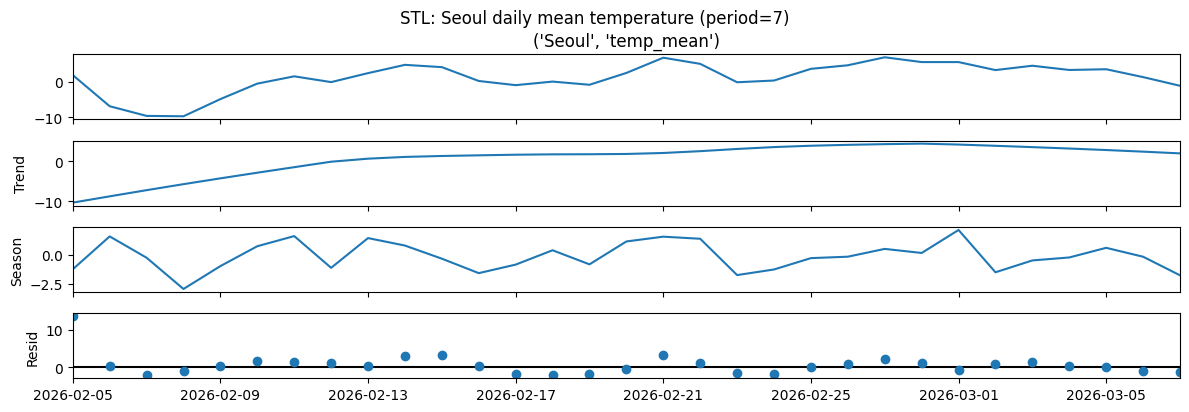

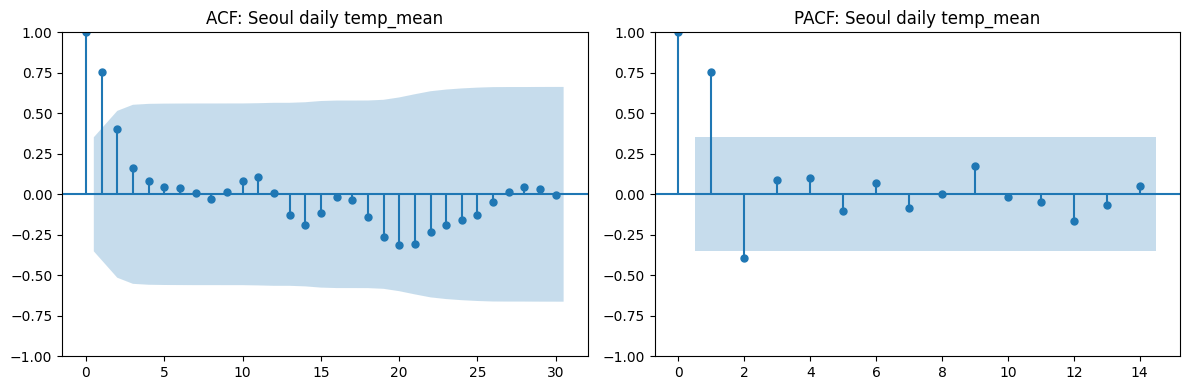

In [17]:
y = df_daily[('Seoul', 'temp_mean')].dropna()

stl = STL(y, period=7, robust=True)
res = stl.fit()
res.plot(); plt.suptitle('STL: Seoul daily mean temperature (period=7)', y=1.02); plt.show()

fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(y, lags=30, ax=ax[0]); ax[0].set_title('ACF: Seoul daily temp_mean')
plot_pacf(y, lags=14, ax=ax[1], method='ywm'); ax[1].set_title('PACF: Seoul daily temp_mean')
plt.tight_layout(); plt.show()

### 🔎 출력 해석 포인트 (진단(STL/ACF))
- 일별 기온은 추세(계절)와 주간 패턴(약할 수도 있음)이 함께 나타날 수 있습니다.
- STL은 Trend/Seasonal/Residual로 구조를 분해해 해석을 돕습니다.
- ACF는 자기상관 구조를 보여주며, 예측 베이스라인(예: yesterday, last week)을 설계하는 힌트를 줍니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. STL의 구성요소는 (_____), (_____), (_____)이다.
- Q2. 일별 데이터에서 주간 패턴을 보면 보통 period=(_____)를 사용한다.
- Q3. ACF는 시차별 (_____) 구조를 보여준다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. Trend
- A2. Seasonal
- A3. Residual
- A4. 7
- A5. 자기상관(autocorrelation)

</details>


## 9) 간단 예측(일별): Seasonal Naïve(7일) — Seoul temp_mean
일별 평균기온의 ‘지난주 오늘’ 값을 그대로 쓰는 Seasonal Naïve는 교육용 기준선으로 매우 유용합니다.


Seasonal Naive(h=7) | RMSE=3.911, MAE=3.122


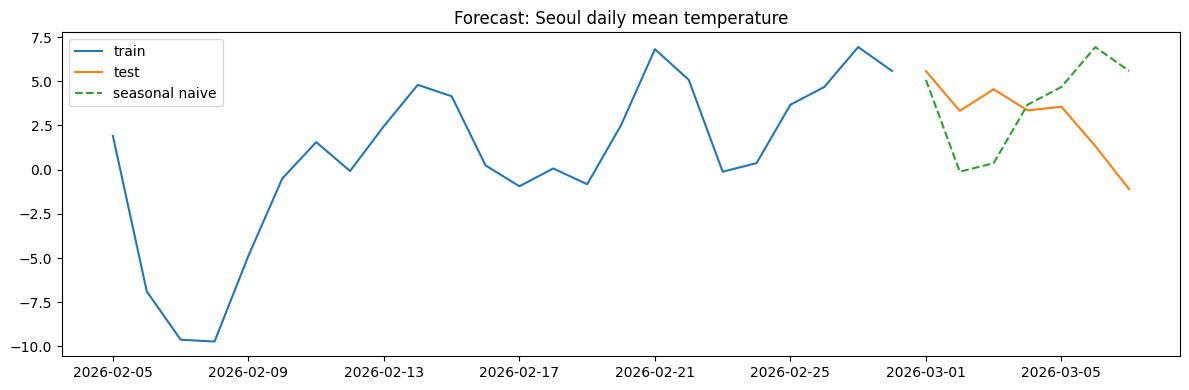

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

h = 7
y2 = y.copy()
test_n = 7  # 마지막 7일 테스트
y_train = y2.iloc[:-test_n]
y_test  = y2.iloc[-test_n:]

y_pred = y_test.copy()*np.nan
for t in y_test.index:
    t_lag = t - pd.Timedelta(days=h)
    if t_lag in y2.index:
        y_pred.loc[t] = y2.loc[t_lag]

rmse = math.sqrt(mean_squared_error(y_test.dropna(), y_pred.dropna()))
mae  = mean_absolute_error(y_test.dropna(), y_pred.dropna())
print(f'Seasonal Naive(h={h}) | RMSE={rmse:.3f}, MAE={mae:.3f}')

plt.figure(figsize=(12,4))
plt.plot(y_train.index, y_train, label='train')
plt.plot(y_test.index, y_test, label='test')
plt.plot(y_pred.index, y_pred, label='seasonal naive', linestyle='--')
plt.title('Forecast: Seoul daily mean temperature')
plt.legend(); plt.tight_layout(); plt.show()


### 🔎 출력 해석 포인트 (예측 해석)
- Seasonal Naïve는 ‘지난주 오늘’이라는 강력한 기준선입니다.
- 날씨는 계절/추세가 있어 긴 기간에서는 더 복잡한 모델이 유리할 수 있습니다.
- 하지만 교육에서는 ‘베이스라인 대비 개선’이라는 사고방식이 중요합니다.

### ✅ Comprehension Check (과제형)
**빈칸 채우기**

- Q1. Seasonal Naïve(h=7)는 ŷ_t = y_{t-(_____) }이다.
- Q2. 날씨 시계열에서 강한 반복 패턴은 보통 (_____)주기(일주기/주간/연간)에서 나타난다.
- Q3. 모형 성능은 항상 (_____)과 비교해 해석한다.

<details>
<summary>정답 예시(펼치기)</summary>

- A1. 7
- A2. 일주기(24시간) 또는 연간(계절)
- A3. 베이스라인

</details>


## ✅ 마무리 (요약 3줄)
1) Open-Meteo는 **가입/키 없이** 전세계 도시의 시간별 날씨 시계열을 쉽게 수집할 수 있습니다.
2) 시간별 데이터는 **시간대(timezone)**와 **리샘플링(시간→일)** 처리가 핵심 실무 포인트입니다.
3) 교육에서는 STL/ACF로 패턴을 진단한 뒤, Seasonal Naïve 같은 베이스라인부터 비교하며 예측을 확장하는 흐름이 효과적입니다.

### ➡️ 다음 노트북 연결
- 다음 단계에서는 (1) 일별/시간별 데이터에서 ARIMA/SARIMA를 적용하거나,
- (2) 도시별 다변량(VAR) 혹은 외생변수(습도/풍속) 포함 회귀(ARIMAX)로 확장할 수 있습니다.
